# BTVN (Bản mở rộng): Transfer Learning & YOLO Video/Webcam

**Chủ đề:** Fine-tune ResNet/EfficientNet với `ImageFolder`, và demo **YOLOv8** trên video/webcam.

In [1]:
import os, sys, time, copy
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch, torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Thiết bị:", device)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

PyTorch: 2.9.0+cpu
TorchVision: 0.24.0+cpu
Thiết bị: cpu


In [2]:
data_dir = r"D:\năm 4\PythonSGU\BaiTap+BaiGiangML\BaiTap\BT5_ML03\data_dir"   # <-- THAY BẰNG THƯ MỤC CỦA BẠN

batch_size = 16
num_workers = 2
epochs = 5          # thử nhỏ trước (5-10), sau đó tăng
lr = 1e-3
use_mixup = False   # set True nếu muốn bật mixup đơn giản

train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


In [3]:

from torchvision.datasets import ImageFolder

train_dir = os.path.join(data_dir, "train")
val_dir   = os.path.join(data_dir, "value")

train_ds = ImageFolder(train_dir, transform=train_tf)
val_ds   = ImageFolder(val_dir,   transform=val_tf)

num_classes = len(train_ds.classes)
class_names = train_ds.classes
print("Classes:", class_names)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader   = DataLoader(val_ds,   batch_size=batch_size*2, shuffle=False, num_workers=num_workers)


Classes: ['class_cat', 'class_dog', 'class_food', 'class_groceryproducts', 'class_plant']


In [4]:
def train_one_epoch(model, loader, optimizer, criterion, epoch, use_mixup=False):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (images, targets) in enumerate(loader):
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()
        if use_mixup:
            inputs, y_a, lam, y_b = mixup_data(images, targets, alpha=0.4)
            outputs = model(inputs)
            loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
            preds = outputs.argmax(dim=1)
            # ước lượng accuracy thô (không chính xác với mixup, chỉ tham khảo)
            correct += (preds == targets).sum().item()
        else:
            outputs = model(images)
            loss = criterion(outputs, targets)
            preds = outputs.argmax(dim=1)
            correct += (preds == targets).sum().item()

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        total += images.size(0)

    return running_loss / total, correct / total


In [5]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_tgts = [], []

    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        outputs = model(images)
        loss = criterion(outputs, targets)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += images.size(0)

        all_preds.append(preds.cpu().numpy())
        all_tgts.append(targets.cpu().numpy())

    avg_loss = running_loss / total
    acc = correct / total
    all_preds = np.concatenate(all_preds)
    all_tgts = np.concatenate(all_tgts)
    return avg_loss, acc, all_preds, all_tgts


### 1.1) Chọn backbone: ResNet18 hoặc EfficientNet-B0

In [6]:
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn
import torch.optim as optim

backbone = "resnet18"  # "resnet18" hoặc "efficientnet_b0"

if backbone == "resnet18":
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
elif backbone == "efficientnet_b0":
    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
else:
    raise ValueError("Backbone không hợp lệ")

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)


### 1.2) Huấn luyện & đánh giá

In [7]:
best_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

for epoch in range(1, epochs+1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, epoch, use_mixup=use_mixup)
    val_loss, val_acc, val_preds, val_tgts = evaluate(model, val_loader, criterion)

    if val_acc > best_acc:
        best_acc = val_acc
        best_wts = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch:02d} | train_loss={tr_loss:.4f} acc={tr_acc:.4f} | val_loss={val_loss:.4f} acc={val_acc:.4f}")

# Load best
model.load_state_dict(best_wts)
print(f"Best val acc: {best_acc:.4f}")


Epoch 01 | train_loss=0.1094 acc=0.9616 | val_loss=0.0609 acc=0.9778
Epoch 02 | train_loss=0.0501 acc=0.9826 | val_loss=0.0408 acc=0.9845
Epoch 03 | train_loss=0.0352 acc=0.9872 | val_loss=0.0266 acc=0.9899
Epoch 04 | train_loss=0.0283 acc=0.9898 | val_loss=0.0209 acc=0.9920
Epoch 05 | train_loss=0.0241 acc=0.9914 | val_loss=0.0562 acc=0.9800
Best val acc: 0.9920


Validation acc: 0.9800
                       precision    recall  f1-score   support

            class_cat       0.95      0.93      0.94     12500
            class_dog       0.85      0.98      0.91     12500
           class_food       1.00      0.98      0.99    101000
class_groceryproducts       0.94      0.96      0.95       634
          class_plant       1.00      1.00      1.00     17572

             accuracy                           0.98    144206
            macro avg       0.95      0.97      0.96    144206
         weighted avg       0.98      0.98      0.98    144206



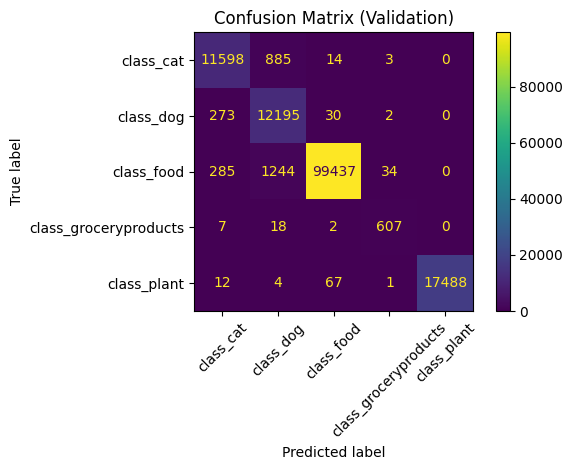

In [12]:
# Báo cáo phân loại & Confusion Matrix
# val_loss, val_acc, val_preds, val_tgts = evaluate(model, val_loader, criterion)
print(f"Validation acc: {val_acc:.4f}")
print(classification_report(val_tgts, val_preds, target_names=class_names))

cm = confusion_matrix(val_tgts, val_preds, labels=list(range(num_classes)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix (Validation)")
plt.tight_layout()
plt.show()


In [9]:
# Lưu model tốt nhất
save_path = f"./fine_tuned_{backbone}_{len(class_names)}cls_best.pth"
torch.save(model.state_dict(), save_path)
print("Đã lưu:", save_path)


Đã lưu: ./fine_tuned_resnet18_5cls_best.pth


Kết quả dự đoán: dog
Xác suất: 0.9882424473762512


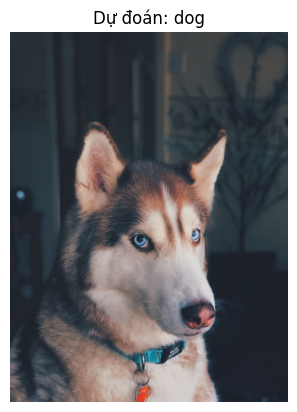

In [4]:
import torch
from torchvision.models import resnet18
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# --- 1️⃣ Tạo lại kiến trúc ---
num_classes = 5  # sửa theo số lớp bạn huấn luyện
model = resnet18(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)

# --- 2️⃣ Load lại trọng số ---
model.load_state_dict(torch.load("./fine_tuned_resnet18_5cls_best.pth", map_location="cpu"))
model.eval()

# --- 3️⃣ Transform ảnh ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- 4️⃣ Đường dẫn ảnh test ---
img_path = r"D:\năm 4\PythonSGU\BaiTap+BaiGiangML\BaiTap\img\dog_alaska.jpg"
img = Image.open(img_path).convert("RGB")
x = transform(img).unsqueeze(0)

# --- 5️⃣ Dự đoán ---
with torch.no_grad():
    pred = model(x)
    prob = torch.softmax(pred, dim=1)
    label_id = prob.argmax(dim=1).item()

# --- 6️⃣ Hiển thị ---
class_names = ['cat', 'dog', 'plant', 'car', 'person']  # sửa theo của bạn
print("Kết quả dự đoán:", class_names[label_id])
print("Xác suất:", prob[0, label_id].item())

plt.imshow(img)
plt.title(f"Dự đoán: {class_names[label_id]}")
plt.axis("off")
plt.show()


### 1.3) Suy luận 1 ảnh đơn lẻ

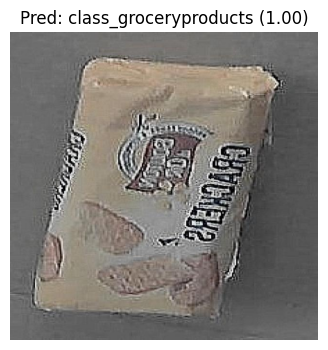

In [10]:

from torchvision.transforms.functional import to_pil_image

def predict_image(model, img_path, size=224):
    model.eval()
    img = Image.open(img_path).convert("RGB")
    tfm = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(size),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    x = tfm(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        prob = torch.softmax(logits, dim=1)[0].cpu().numpy()
        cls = int(np.argmax(prob))
    return img, cls, prob[cls]

# Ví dụ: thay đường dẫn ảnh bên dưới
test_img_path = r"D:\năm 4\PythonSGU\BaiTap+BaiGiangML\BaiTap\BT5_ML03\data_dir\value\class_groceryproducts\biscuit_WIN_20240125_11_30_32_Pro-jpg_2_jpg.rf.149a1efdb7959ec32efbb00f872b5d0c.jpg"
img, cls, p = predict_image(model, test_img_path)
plt.figure(figsize=(4,4)); plt.imshow(img); plt.axis("off")
plt.title(f"Pred: {class_names[cls]} ({p:.2f})")
plt.show()


## 2) YOLOv8: Video/Webcam Demo

- Yêu cầu: `pip install ultralytics opencv-python`  
- **Webcam**: `source=0` (có thể cần quyền camera).  
- **Video file**: đặt `VIDEO_PATH` tới file `.mp4`/`.avi` của bạn.

In [11]:
from ultralytics import YOLO
import cv2

USE_WEBCAM = False
VIDEO_PATH = r"D:\năm 4\PythonSGU\BaiTap+BaiGiangML\BaiTap\videos\people_walking.mp4"  # <-- THAY BẰNG ĐƯỜNG DẪN VIDEO CỦA BẠN

model = YOLO("yolov8n.pt")

# Kích thước tối đa của cửa sổ hiển thị (giữ tỉ lệ ảnh)
DISPLAY_MAX_W, DISPLAY_MAX_H = 1280, 720   # bạn có thể đổi 960x540, 1024x576,...

if USE_WEBCAM:
    cap = cv2.VideoCapture(0)
else:
    cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    print("Không mở được nguồn video/webcam. Kiểm tra đường dẫn hoặc quyền camera.")
else:
    window_name = "YOLOv8 — Press 'q' to quit"
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)  # cửa sổ có thể co kéo

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # (1) Chạy YOLO — có thể đặt imgsz để nhẹ hơn
        results = model(frame, conf=0.50, imgsz=640, verbose=False)

        # (2) Vẽ kết quả với bbox dày hơn, chữ lớn hơn
        annotated = results[0].plot(line_width=3, font_size=0.7)  # tăng độ dày & font

        # (3) Resize ảnh *chỉ để hiển thị* (giữ tỉ lệ)
        h, w = annotated.shape[:2]
        scale = min(DISPLAY_MAX_W / w, DISPLAY_MAX_H / h, 1.0)   # không phóng to quá mức
        if scale < 1.0:
            new_w, new_h = int(w * scale), int(h * scale)
            annotated = cv2.resize(annotated, (new_w, new_h), interpolation=cv2.INTER_AREA)

        cv2.imshow(window_name, annotated)

        # (4) Phím tắt: q = thoát, + / - để thay đổi kích thước mục tiêu
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key in (43, ord('+')):  # tăng
            DISPLAY_MAX_W = min(DISPLAY_MAX_W + 160, 1920)
            DISPLAY_MAX_H = min(DISPLAY_MAX_H + 90, 1080)
        elif key in (45, ord('-')):  # giảm
            DISPLAY_MAX_W = max(DISPLAY_MAX_W - 160, 480)
            DISPLAY_MAX_H = max(DISPLAY_MAX_H - 90, 270)

    cap.release()
    cv2.destroyAllWindows()
